<a href="https://colab.research.google.com/github/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/blob/main/Project%201/%5BProject_1%5D_Phase_2_Data_Audit_%26_Forensics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
# Phase 2: Data Audit & Forensics
# Step 2.1: Establishing the "Digital Portfolio"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 56 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   stdntid          1780 non-null   int64  
 1   gender           1696 non-null   float64
 2   race             1134 non-null   float64
 3   preschol         1347 non-null   float64
 4   kindrgrt         1579 non-null   float64
 5   birthmonth       1331 non-null   float64
 6   birthday         1331 non-null   float64
 7   birthyear        1331 non-null   float64
 8   flagg1c          1780 non-null   int64  
 9   flagg2c          1780 non-null   int64  
 10  flagg3c          1780 non-null   int64  
 11  g1schid          1315 non-null   float64
 12  g1tchid          1312 non-null   float64
 13  g1classsize      1312 non-null   float64
 14  g1treadss        1181 non-null   float64
 15  g1tmathss        1180 non-null   float64
 16  g1tlistss        1177 non-null   float64
 17  g1wordskillss 

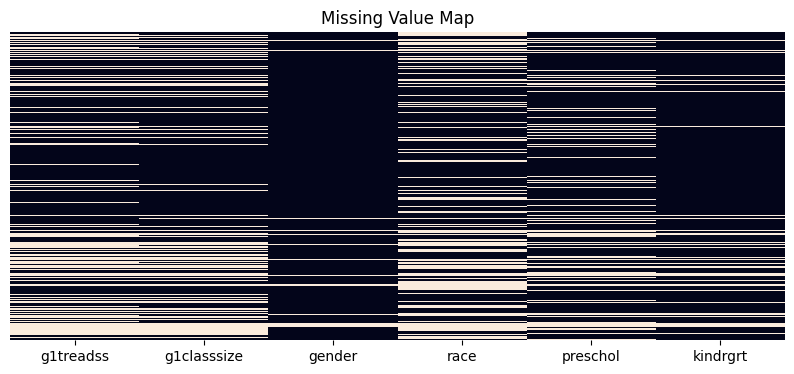

Missing Value Strategy:
g1treadss  : 33.65% thus drop rows (Y cannot be missing)
g1classsize: 26.29% thus drop rows (D cannot be missing)
gender     : 4.72% thus acceptable, retain available rows
race       : 36.29% thus HIGH - MAR threat, retain rows
preschol   : 24.33% thus HIGH - MAR threat, retain rows
kindrgrt   : 11.29% thus moderate, retain rows

Note: race and preschol show structural missingness (MAR).
Dropping these rows would introduce selection bias.
Strategy: retain rows, missing controls handled in regression stage.
Rows before dropna: 1780
Rows after dropna : 1178
Rows dropped       : 602


In [41]:
# Step 2.2: Ingestion and "Dirty Data" Forensics

# Load the data
df = pd.read_csv('Comparison_Students.tab.csv')
df.head()


# Task 1: Shape and Types Audit
df.shape


df.info()


df.describe()


# Manual cleaning required by "Foundations First" policy
df['g1classsize'] = pd.to_numeric(df['g1classsize'], errors='coerce')
df['g1treadss']   = pd.to_numeric(df['g1treadss'],   errors='coerce')
df['gender']      = pd.to_numeric(df['gender'],       errors='coerce')
df['race']        = pd.to_numeric(df['race'],         errors='coerce')
df['preschol']    = pd.to_numeric(df['preschol'],     errors='coerce')
df['kindrgrt']    = pd.to_numeric(df['kindrgrt'],     errors='coerce')

print("Data types after cleaning:")
print(df[['g1treadss', 'g1classsize', 'gender', 'race', 'preschol', 'kindrgrt']].dtypes)


# Task 2: Missing Value Strategy (MCAR vs. MAR)
df_star = df[['g1treadss', 'g1classsize', 'gender', 'race', 'preschol', 'kindrgrt']].copy()

# Count missing values
df_star.isnull().sum()


# Missing % per variable
missing_pct = (df_star.isnull().sum() / len(df_star) * 100).round(2)
print(missing_pct)

# Listwise deletion (dropna) is only acceptable if missingness is < 5% and random
# Variables above 5% suggest structural missingness (MAR), threat to internal validity


# Visualize missingness
plt.figure(figsize=(10, 4))
sns.heatmap(df_star.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Value Map")
plt.show()

# Missing Value Decision Documentation
# dropna() on all variables would drop 60% of data, way too aggressive
# race (36%) and preschol (24%) show structural missingness (MAR)
# Blindly dropping these rows would introduce selection bias
# Strategy: only require Y and D to be non-null for the core analysis
print("Missing Value Strategy:")
print(f"g1treadss  : {missing_pct['g1treadss']}% thus drop rows (Y cannot be missing)")
print(f"g1classsize: {missing_pct['g1classsize']}% thus drop rows (D cannot be missing)")
print(f"gender     : {missing_pct['gender']}% thus acceptable, retain available rows")
print(f"race       : {missing_pct['race']}% thus HIGH - MAR threat, retain rows")
print(f"preschol   : {missing_pct['preschol']}% thus HIGH - MAR threat, retain rows")
print(f"kindrgrt   : {missing_pct['kindrgrt']}% thus moderate, retain rows")
print()
print("Note: race and preschol show structural missingness (MAR).")
print("Dropping these rows would introduce selection bias.")
print("Strategy: retain rows, missing controls handled in regression stage.")

# Only drop rows where Y or D are missing, controls can have NaN
df_clean = df_star.dropna(subset=['g1treadss', 'g1classsize'])

print("Rows before dropna:", len(df_star))
print("Rows after dropna :", len(df_clean))
print("Rows dropped       :", len(df_star) - len(df_clean))




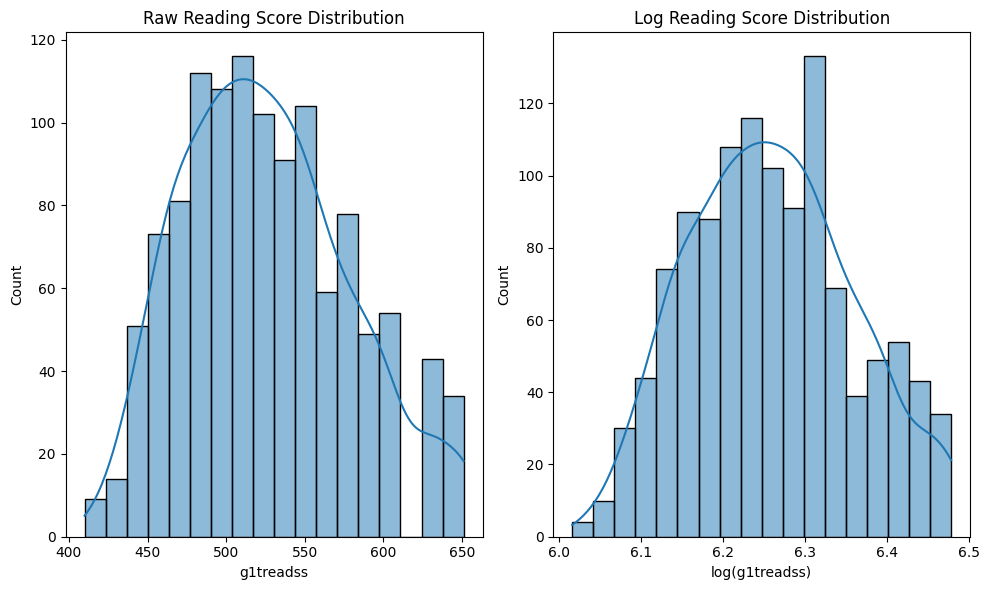

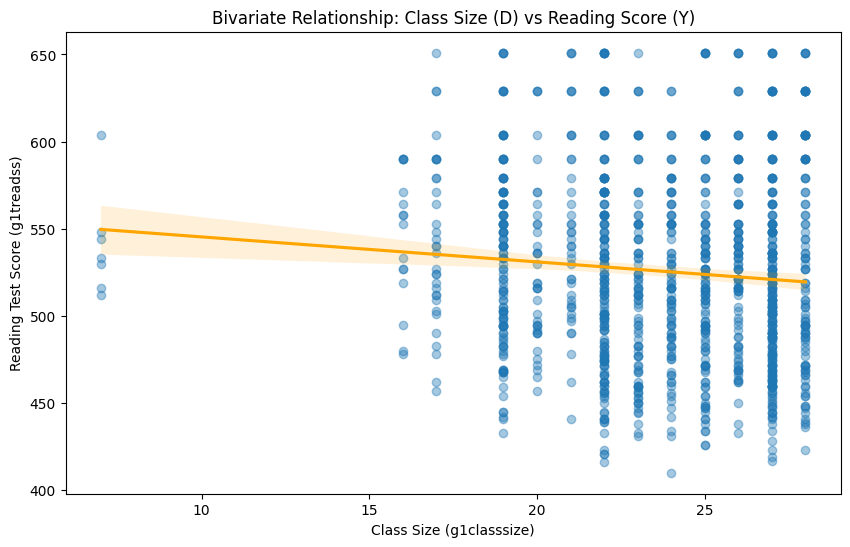

Q1            : 487.00
Q3            : 558.00
IQR           : 71.00
Lower Fence   : 380.50
Upper Fence   : 664.50
Outliers found: 0


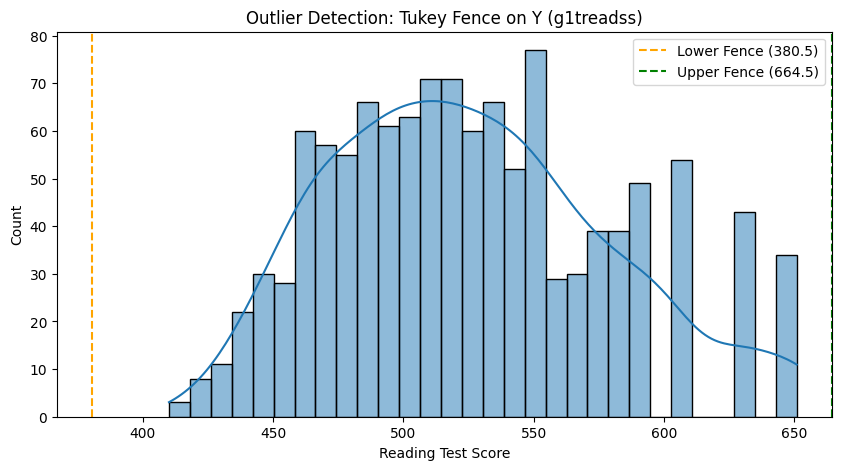

Rows in df_clean      : 1178
Rows in df_no_outliers: 1178
Outliers removed      : 0


In [42]:
# Step 2.3: Exploratory Data Analysis (EDA) as Visual Forensics

# Requirement 1: Univariate Distribution (The "Money Illusion" Check)

# Filter before log transform to avoid log(0) errors
df_clean = df_clean[df_clean['g1treadss'] > 0].copy()
df_clean['log_g1treadss'] = np.log(df_clean['g1treadss'])

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['g1treadss'], kde=True)
plt.title("Raw Reading Score Distribution")
plt.xlabel("g1treadss")

plt.subplot(1, 2, 2)
sns.histplot(df_clean['log_g1treadss'], kde=True)
plt.title("Log Reading Score Distribution")
plt.xlabel("log(g1treadss)")

plt.tight_layout()
plt.show()


# Requirement 2: Bivariate Relationship

plt.figure(figsize=(10, 6))
sns.regplot(x='g1classsize', y='g1treadss', data=df_clean,
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'orange'})
plt.title("Bivariate Relationship: Class Size (D) vs Reading Score (Y)")
plt.xlabel("Class Size (g1classsize)")
plt.ylabel("Reading Test Score (g1treadss)")
plt.show()

# Requirement 3: Outlier Detection (Tukey Fence Method IQR x 1.5)

Q1  = df_clean['g1treadss'].quantile(0.25)
Q3  = df_clean['g1treadss'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['g1treadss'] < lower_fence) | (df_clean['g1treadss'] > upper_fence)]

print(f"Q1            : {Q1:.2f}")
print(f"Q3            : {Q3:.2f}")
print(f"IQR           : {IQR:.2f}")
print(f"Lower Fence   : {lower_fence:.2f}")
print(f"Upper Fence   : {upper_fence:.2f}")
print(f"Outliers found: {len(outliers)}")


# Visualize outliers on the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['g1treadss'], bins=30, kde=True)
plt.axvline(lower_fence, color='orange',    linestyle='--', label=f'Lower Fence ({lower_fence:.1f})')
plt.axvline(upper_fence, color='green', linestyle='--', label=f'Upper Fence ({upper_fence:.1f})')
plt.title("Outlier Detection: Tukey Fence on Y (g1treadss)")
plt.xlabel("Reading Test Score")
plt.legend()
plt.show()


# Keep original df_clean intact, so save cleaned version separately
df_no_outliers = df_clean[(df_clean['g1treadss'] >= lower_fence) &
                           (df_clean['g1treadss'] <= upper_fence)]

print("Rows in df_clean      :", len(df_clean))
print("Rows in df_no_outliers:", len(df_no_outliers))
print("Outliers removed      :", len(df_clean) - len(df_no_outliers))